[Variable Glossary](#Variable-Glossary)
<br>
[Visualizing each feature](#Visualizing-each-feature)
<br>
[Correlation Matricies](#correlation-matricies)
<br>
[Crosstabs](#crosstabs)
<br>
[Data Cleaning](#correlation-matricies)
<br>
[Data Prep](#moving-on-to-the-rest-of-the-data-prep)
<br>
[Building Models](#moving-back-to-building-models)
<br>
[SMOTE](#smote)
<br>
[SVM](#svm)

# Variable Glossary
- definition
- correlation
- scatterplot

In [5]:
import pandas as pd
import numpy as np
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import chi2_contingency

In [70]:
filename = "celiac_disease_lab_data.csv"
df = pd.read_csv(filename)
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,Yes,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,Yes,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,Yes,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes


In [7]:
df.dtypes

Age                   int64
Gender               object
Diabetes             object
Diabetes_Type        object
Diarrhea             object
Abdominal            object
Short_Stature        object
Sticky_Stool         object
Weight_loss          object
IgA                 float64
IgG                 float64
IgM                 float64
Marsh                object
cd_type              object
Disease_Diagnose     object
dtype: object

In [8]:
df["Diabetes_Type"] = df["Diabetes_Type"].fillna(0)

In [9]:
df.isna().sum()

Age                 0
Gender              0
Diabetes            0
Diabetes_Type       0
Diarrhea            0
Abdominal           0
Short_Stature       0
Sticky_Stool        0
Weight_loss         0
IgA                 0
IgG                 0
IgM                 0
Marsh               0
cd_type             0
Disease_Diagnose    0
dtype: int64

In [10]:
df.duplicated().sum()

1557

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(649, 15)

In [13]:
df_num = df.select_dtypes(include=[np.number])
df_cat = df.select_dtypes(include=['object'])

Visualizing Correlations Between Variables: 
- using a correlation matrix for numeric variables
- using Cramer's V to measure correlation between categorical variables (derived from chi-square)
- using correlation ratio for correlation between categorical and numeric variables (how much of the numeric variation can be explained by the categorical variable's groups)

In [14]:
# starting with age
df['Age'].describe()

count    649.000000
mean      12.636364
std        7.350168
min        1.000000
25%        8.000000
50%       10.000000
75%       15.000000
max       35.000000
Name: Age, dtype: float64

In [15]:
df['IgA'].describe()

count    649.000000
mean       1.401387
std        1.092107
min        0.340000
25%        0.980000
50%        1.100000
75%        1.800000
max        9.000000
Name: IgA, dtype: float64

In [16]:
df['IgG'].describe()

count    649.000000
mean      10.130354
std        1.963734
min        5.000000
25%        9.000000
50%       10.000000
75%       12.000000
max       15.300000
Name: IgG, dtype: float64

In [17]:
df['IgM'].describe()

count    649.000000
mean       1.230200
std        0.440298
min        0.500000
25%        1.000000
50%        1.100000
75%        1.500000
max        2.700000
Name: IgM, dtype: float64

In [18]:
df['Marsh'].describe()

count      649
unique       7
top       none
freq       133
Name: Marsh, dtype: object

In [19]:
df['Disease_Diagnose'].describe()

count     649
unique      2
top       yes
freq      504
Name: Disease_Diagnose, dtype: object

# Visualizing each feature

Starting with numeric features. I tried scatterplots first, and even jittered, they just didn't show anything useful. Box plots and histograms show a lot more about the data. I liked histograms the best.


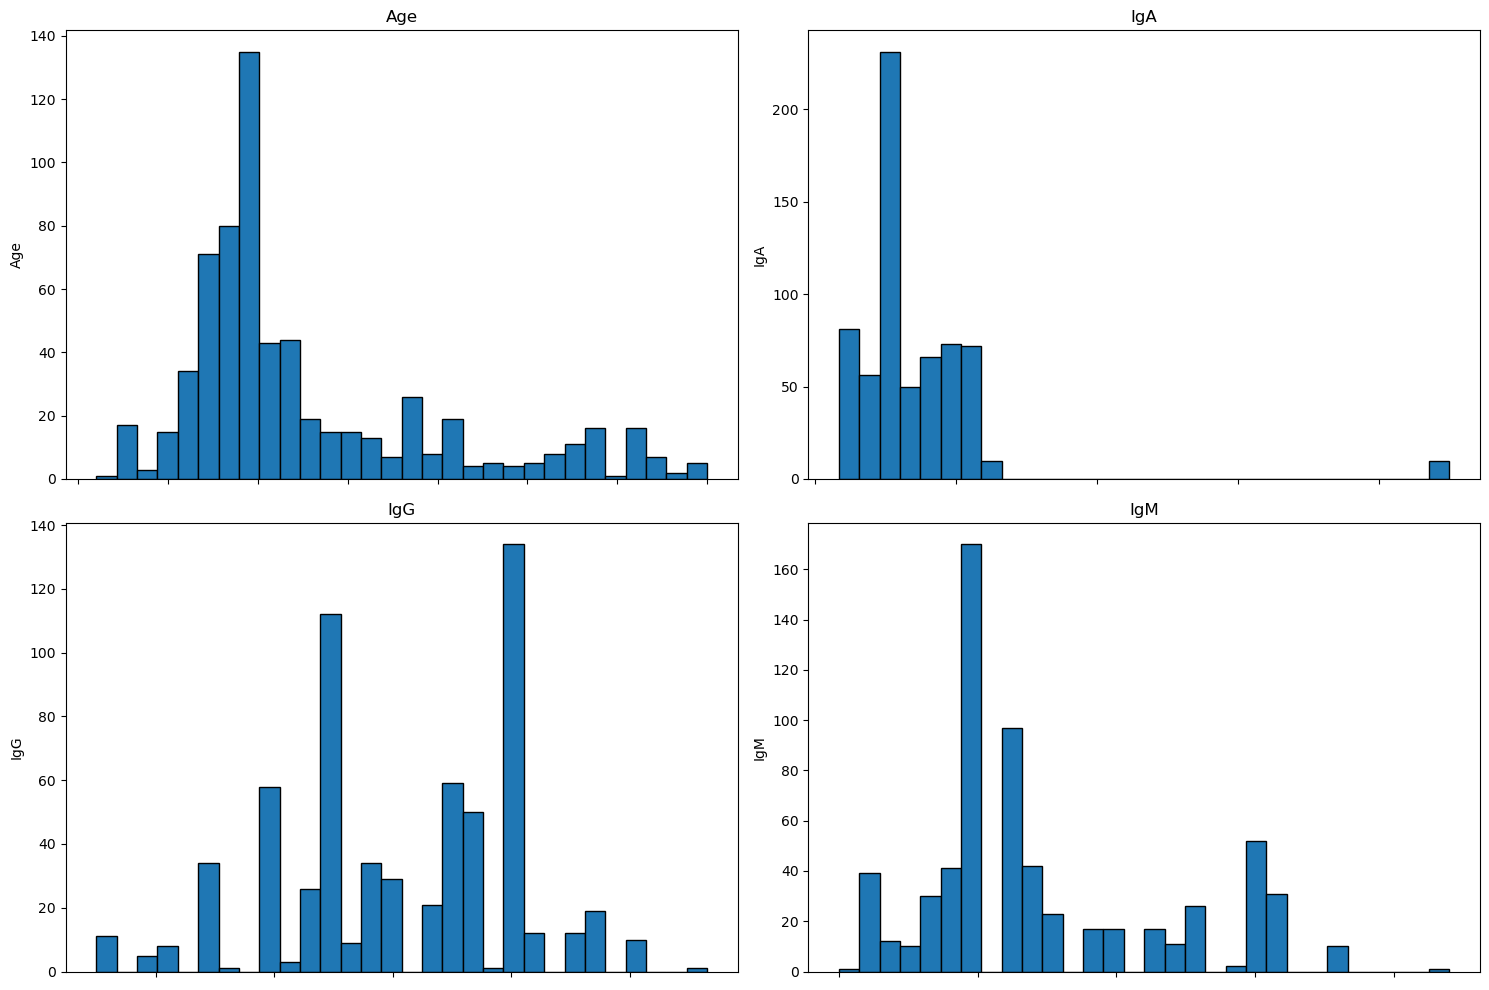

In [20]:
n_features = len(df_num.columns)
ncols = 2
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))   
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    #axes[i].boxplot(df_num[col])
    #axes[i].scatter(range(len(df_num[col])), df_num[col], alpha=0.5)
    axes[i].hist(df_num[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)  
    axes[i].set_xticklabels('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Next, visualize the spread of the categorical variables. We're going to plot using count plots.

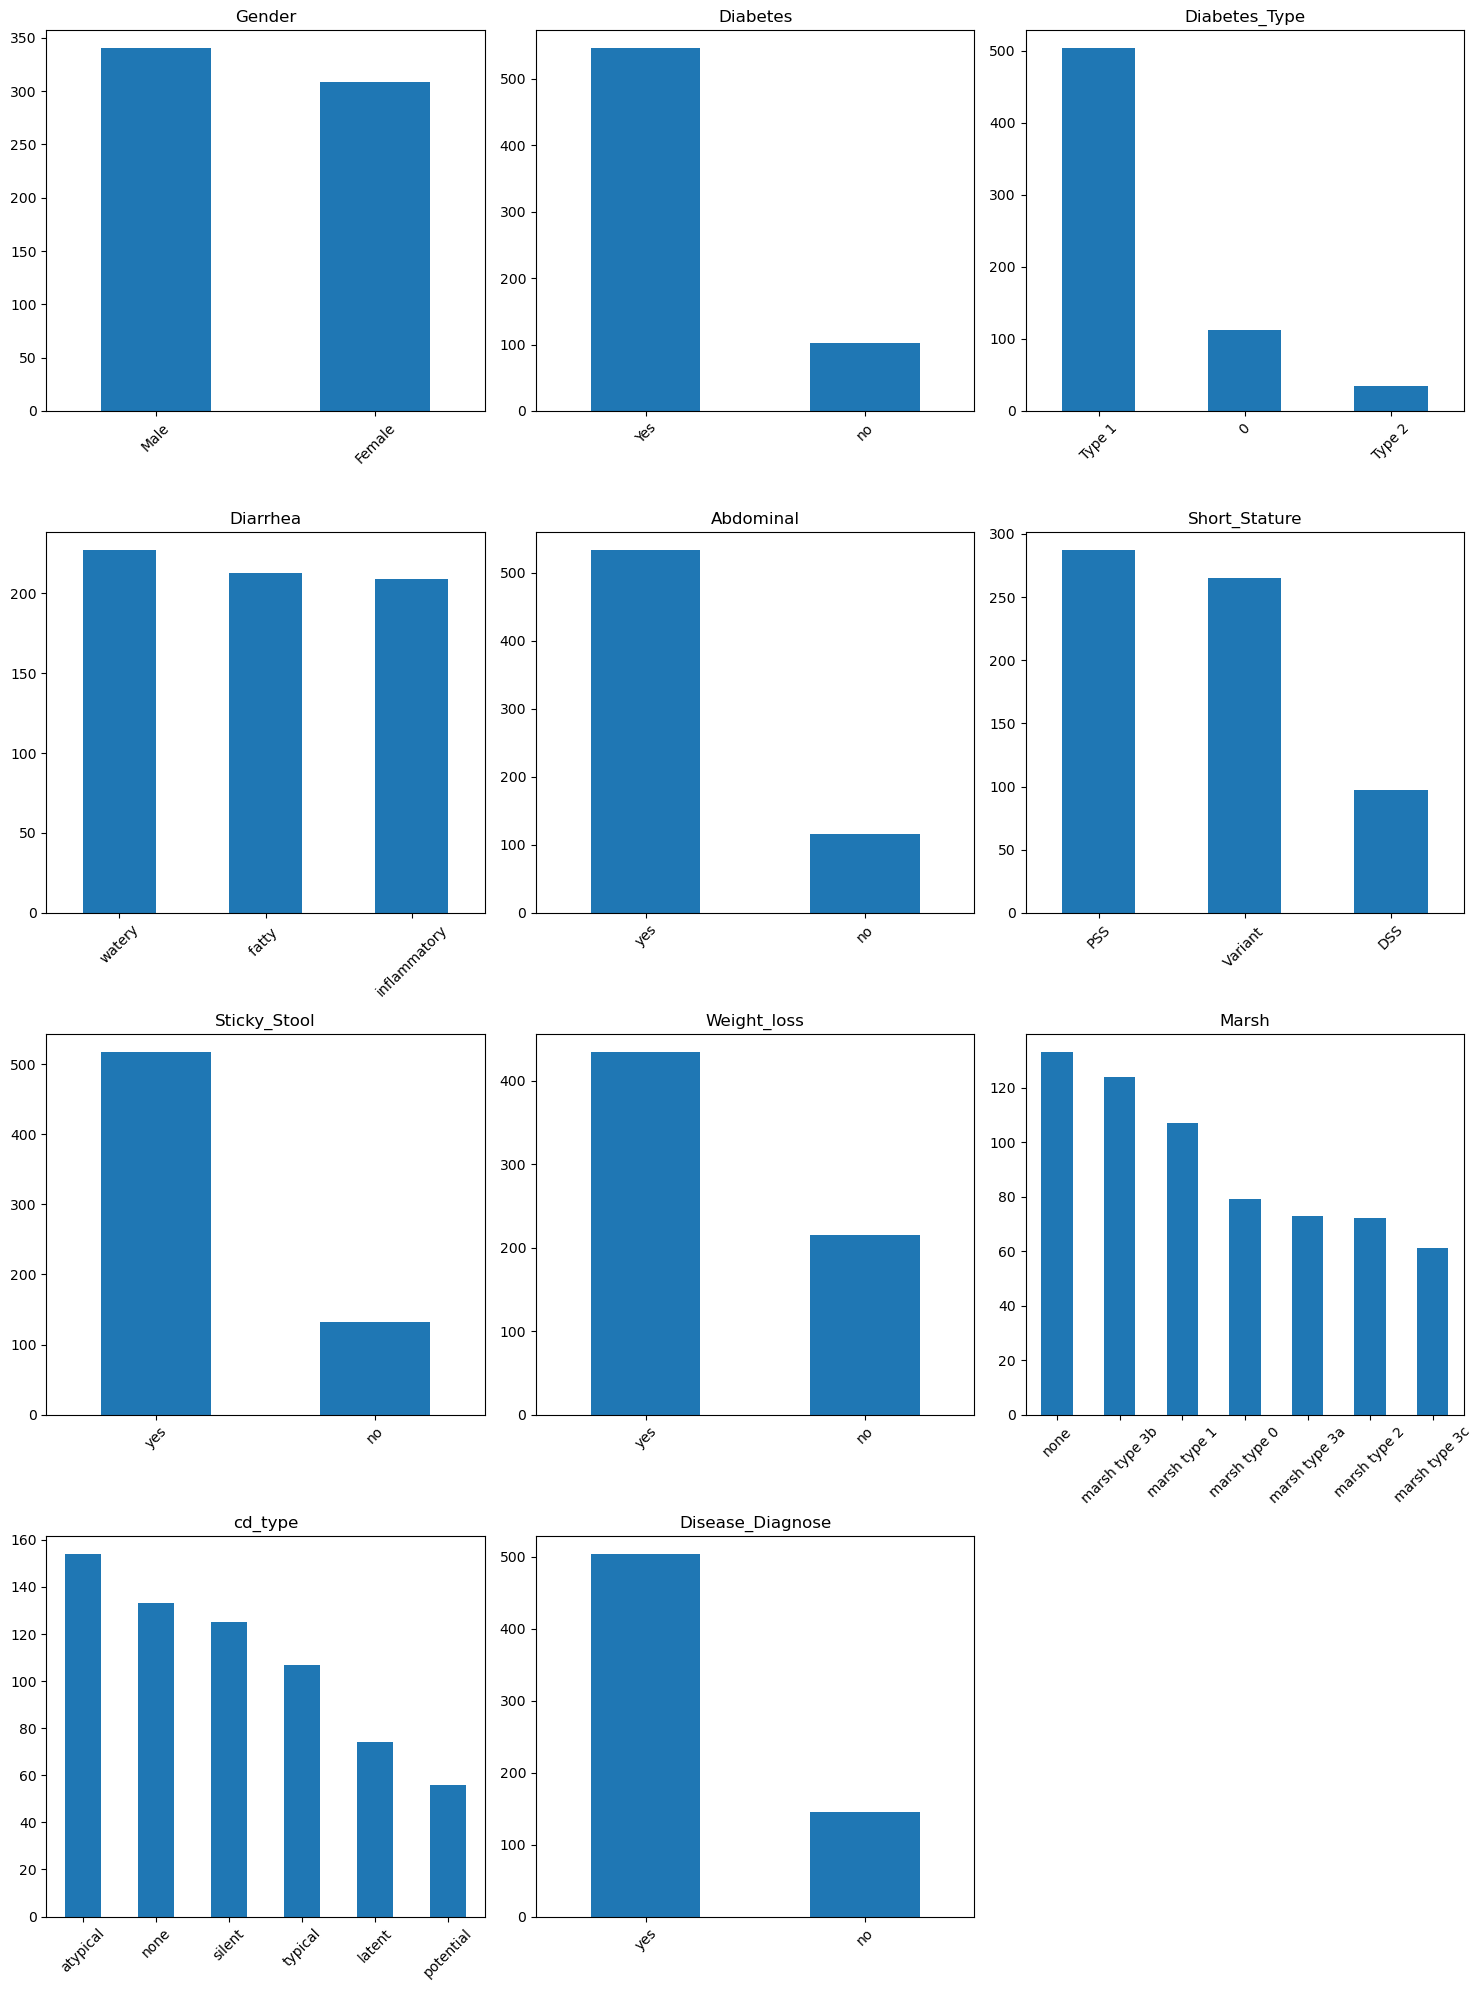

In [21]:
n_features = len(df_cat.columns)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(df_cat.columns):
    df_cat[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# Correlation Matricies

<Axes: >

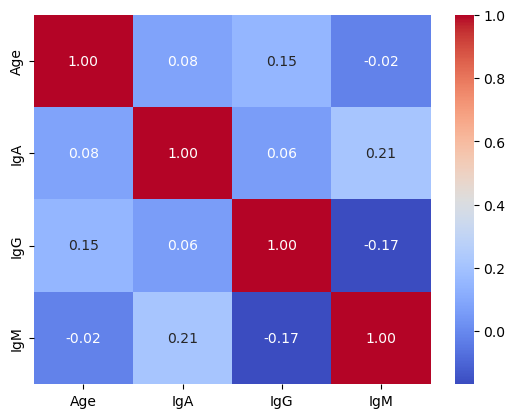

In [22]:
# correlation matrix for numeric variables
correlation_matrix = df_num.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')

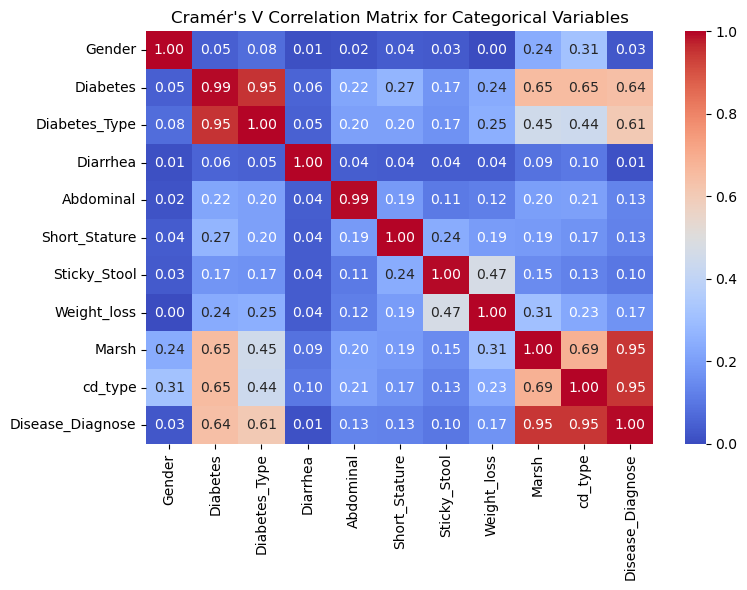

In [23]:
# cramer's v for categorical variables
cramers_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_cat.columns))),
    columns=df_cat.columns,
    index=df_cat.columns
)

for col1 in df_cat.columns:
    for col2 in df_cat.columns:
        contingency_table = pd.crosstab(df_cat[col1], df_cat[col2])
        chi2 = chi2_contingency(contingency_table)[0]
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        cramers_matrix.loc[col1, col2] = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

plt.figure(figsize=(8,6))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0) 
plt.title("Cramér's V Correlation Matrix for Categorical Variables")
plt.tight_layout()
plt.show()


Mixed results here - definitely reinforces that I have to drop marsh and cd_type. marsh almost is disease_diagnose, which makes sense. same with diabetes and diabetes_type. Think I can drop diabetes. Interesting that gender has a much higher correlation with marsh and cd_type than it does with disease_diagnose. Not exactly sure what that means.

In [24]:
df_num.isnull().sum()

Age    0
IgA    0
IgG    0
IgM    0
dtype: int64

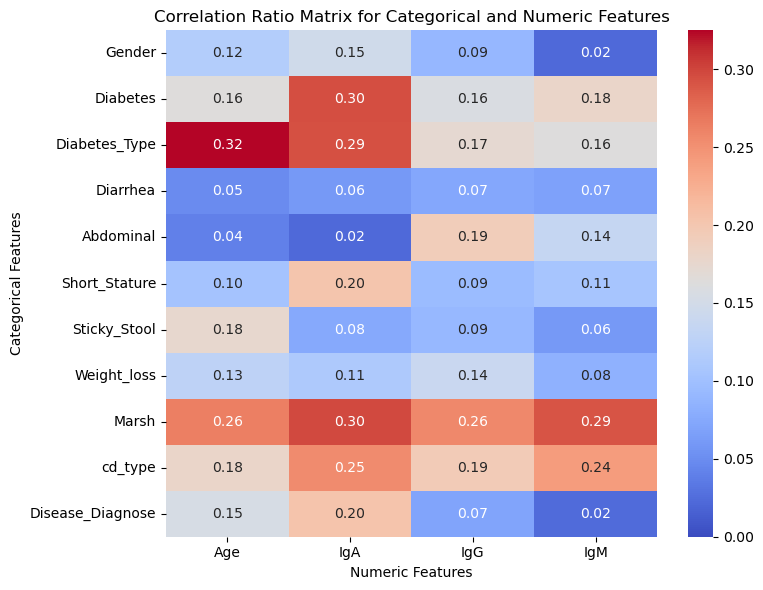

In [25]:
# correlation ratio
mix_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_num.columns))), 
    columns = df_num.columns,
    index = df_cat.columns
)
for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        categories = np.array(df_cat[cat_col].astype(str))
        values = np.array(df_num[num_col])

        # handle nan values
        mask = ~np.isnan(values) | pd.isna(values)
        categories = categories[mask]
        values = values[mask]

        overall_mean = np.mean(values)
        ssw = 0

        for category in np.unique(categories):
            group = values[categories == category]
            ssw += np.sum((group - np.mean(group)) ** 2)

        sst = np.sum((values - overall_mean) ** 2)

        if sst == 0:
            mix_matrix.loc[cat_col, num_col] = 0.0
        else:
            mix_matrix.loc[cat_col, num_col] = np.sqrt(1 - (ssw / sst))

plt.figure(figsize=(8, 6))
sns.heatmap(mix_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0)
plt.title("Correlation Ratio Matrix for Categorical and Numeric Features")
plt.xlabel("Numeric Features")
plt.ylabel("Categorical Features")
plt.tight_layout() 
plt.show()

No super high correlations - means there is no categorical variable perfectly explained by a numeric one. This is good, and it also tells us to look more into the pairings with a higher correlation.

# Crosstabs

Now, to look more specifically at diabetes type and celiac disease:

<Axes: xlabel='Disease_Diagnose', ylabel='Diabetes_Type'>

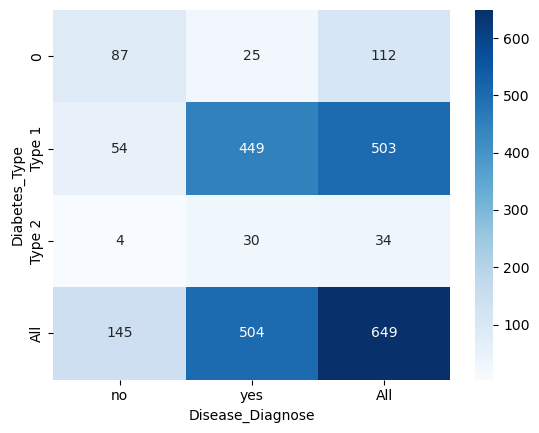

In [26]:
table = pd.crosstab(df['Diabetes_Type'], df['Disease_Diagnose'], margins=True)
sns.heatmap(table, annot=True, fmt="d", cmap='Blues')

Class distribution of diabetes types are not normal at all. Going to have to handle this later
- synthetic oversampling to have equal amounts of t1, t2, and 0?

About 6% of people with T1D have celiac. Compared to the global average of 1%, this is much higher. Elevated risk of celiac disease because both are autoimmune diseases (known genetic link). There is no association or elevated risk with T2D.

# Data Cleaning

Before we build models, we need to drop some features to reduce multicollinearity and data leakage.

In [27]:
df = df.drop(columns=['Marsh', 'cd_type', 'Diabetes'])

In [28]:
df.head(20)

,Age,Gender,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose
0,10,Male,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,yes
1,9,Male,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,yes
2,8,Female,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,yes
3,10,Male,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,yes
4,9,Male,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,yes
5,8,Female,Type 1,fatty,yes,Variant,yes,yes,1.10,9.5,1.00,yes
6,9,Male,Type 1,watery,yes,Variant,yes,yes,2.10,11.4,1.00,yes
7,5,Female,Type 1,fatty,yes,PSS,yes,yes,0.80,12.0,0.98,yes
8,6,Female,Type 1,fatty,yes,PSS,yes,yes,1.50,8.0,1.10,yes
9,4,Male,Type 1,watery,yes,Variant,yes,yes,0.42,11.5,1.00,yes


# Moving on to the rest of the data prep:

In [29]:
df['Abdominal'] = df['Abdominal'].str.lower()
df['Sticky_Stool'] = df['Sticky_Stool'].str.lower()
df['Weight_loss'] = df['Weight_loss'].str.lower()
df['Disease_Diagnose'] = df['Disease_Diagnose'].str.lower()

In [30]:
df.head()

,Age,Gender,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose
0,10,Male,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,yes
1,9,Male,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,yes
2,8,Female,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,yes
3,10,Male,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,yes
4,9,Male,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,yes


In [31]:
df['Abdominal'] = np.where(df['Abdominal'] == 'yes', 1, 0)
df["Sticky_Stool"] = np.where(df["Sticky_Stool"] == 'yes', 1, 0)
df["Weight_loss"] = np.where(df["Weight_loss"] == 'yes', 1, 0)
df["Disease_Diagnose"] = np.where(df["Disease_Diagnose"] == 'yes', 1, 0)
df["Gender"] = np.where(df["Gender"] == 'Male', 1, 0)

In [32]:
df = pd.get_dummies(df,drop_first=True)

In [33]:
df.head()

,Age,Gender,Abdominal,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose,Diabetes_Type_Type 1,Diabetes_Type_Type 2,Diarrhea_inflammatory,Diarrhea_watery,Short_Stature_PSS,Short_Stature_Variant
0,10,1,1,0,0,1.30,10.0,1.00,1,True,False,True,False,True,False
1,9,1,1,0,0,1.50,12.5,1.30,1,True,False,False,False,True,False
2,8,0,1,1,1,0.40,8.0,0.50,1,True,False,False,True,False,True
3,10,1,1,0,0,0.98,9.0,0.66,1,True,False,False,True,True,False
4,9,1,1,0,0,1.00,10.5,1.10,1,True,False,False,False,True,False


# Moving back to building models:

In [34]:
y = df['Disease_Diagnose']
x = df.drop('Disease_Diagnose', axis=1)

In [35]:
X_main, X_test, y_main, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

In [36]:
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.125, stratify=y_main, random_state=42)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [38]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
coefficients = log_model.coef_
intercept = log_model.intercept_

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")

Coefficients: [[ 0.07800635  0.17632763  0.46094223  0.08774421  0.21431933 -0.23138474
  -0.12605274  0.7032162   2.91290709  1.44867449 -0.20439775 -0.19621587
  -0.32688067 -0.6288112 ]]
Intercept: [-1.17471942]


In [40]:
log_model.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1])

In [41]:
y_pred_log = log_model.predict(X_test)
# evaluate the model
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.72      0.62      0.67        29
           1       0.90      0.93      0.91       101

    accuracy                           0.86       130
   macro avg       0.81      0.78      0.79       130
weighted avg       0.86      0.86      0.86       130

[[18 11]
 [ 7 94]]


In [42]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [43]:
lasso_log = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)
lasso_log.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [44]:
y_pred_lasso = lasso_log.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso Coefficients: {lasso_log.coef_}")

Lasso Coefficients: [[ 0.06793053  0.05609023  0.27165664  0.          0.17582716 -0.18398054
  -0.17407602  0.50839413  3.16220543  1.7761201  -0.12508443 -0.13970559
  -0.317809   -0.61627047]]


In [45]:
print(classification_report(y_test, y_pred_lasso))
print(confusion_matrix(y_test, y_pred_lasso))

              precision    recall  f1-score   support

           0       0.70      0.66      0.68        29
           1       0.90      0.92      0.91       101

    accuracy                           0.86       130
   macro avg       0.80      0.79      0.80       130
weighted avg       0.86      0.86      0.86       130

[[19 10]
 [ 8 93]]


In [46]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso_log.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(feature_importance)

                   feature  coefficient
8     Diabetes_Type_Type 1     3.162205
9     Diabetes_Type_Type 2     1.776120
13  Short_Stature_Variant     -0.616270
7                      IgM     0.508394
12       Short_Stature_PSS    -0.317809
2                Abdominal     0.271657
5                      IgA    -0.183981
4              Weight_loss     0.175827
6                      IgG    -0.174076
11         Diarrhea_watery    -0.139706
10   Diarrhea_inflammatory    -0.125084
0                      Age     0.067931
1                   Gender     0.056090
3             Sticky_Stool     0.000000


In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
# Feature importances
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

print(f"Accuracy: {rf.score(X_test, y_test):.3f}")

                   feature  importance
8     Diabetes_Type_Type 1    0.208817
0                      Age    0.138296
6                      IgG    0.135836
7                      IgM    0.124357
5                      IgA    0.121475
11         Diarrhea_watery    0.039699
10   Diarrhea_inflammatory    0.037514
2                Abdominal    0.036531
1                   Gender    0.031887
4              Weight_loss    0.031048
12       Short_Stature_PSS    0.028970
9     Diabetes_Type_Type 2    0.025591
3             Sticky_Stool    0.022337
13  Short_Stature_Variant     0.017641
Accuracy: 0.838


In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],           # number of trees
    'max_depth': [10, 20, 30, None],                # max tree depth
    'min_samples_split': [2, 5, 10],                # min samples to split node
    'min_samples_leaf': [1, 2, 4],                  # min samples in leaf
    'max_features': ['sqrt', 'log2', None],         # features per split
    'class_weight': ['balanced', 'balanced_subsample', None]  # handle imbalance
}

In [62]:
rf_best = RandomForestClassifier(random_state=42)

In [63]:
grid_search = GridSearchCV(
    estimator= rf_best,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1, # to use all cpu cores since this is a hefty task
    verbose=2
)

In [64]:
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Best parameters: {'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 score: 0.9320


In [65]:
best_rf = grid_search.best_estimator_

In [67]:
y_pred_tuned = best_rf.predict(X_test)
y_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned model performance:")
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

Tuned model performance:
              precision    recall  f1-score   support

           0       0.95      0.62      0.75        29
           1       0.90      0.99      0.94       101

    accuracy                           0.91       130
   macro avg       0.92      0.81      0.85       130
weighted avg       0.91      0.91      0.90       130

[[ 18  11]
 [  1 100]]


Going to try to improve predictions for people without celiac disease.

In [71]:
from imblearn.over_sampling import SMOTE

In [72]:
smote_model = SMOTE(sampling_strategy='minority', random_state=42)
x_resampled, y_resampled = smote_model.fit_resample(X_train, y_train)
y_resampled.value_counts()


Disease_Diagnose
1    353
0    353
Name: count, dtype: int64

In [73]:
smote_log = LogisticRegression(max_iter=1000)
smote_log.fit(x_resampled, y_resampled)
smote_log_pred = smote_log.predict(X_test)
print(classification_report(y_test, smote_log_pred))
print(confusion_matrix(y_test, smote_log_pred))

              precision    recall  f1-score   support

           0       0.60      0.62      0.61        29
           1       0.89      0.88      0.89       101

    accuracy                           0.82       130
   macro avg       0.74      0.75      0.75       130
weighted avg       0.83      0.82      0.82       130

[[18 11]
 [12 89]]


Since this model performed worse than the last randomForest model, we can assume there are nonlinear patterns in the data that regression cannot measure. We are going to use a randomForest model on the oversampled data.

# SMOTE

In [76]:
# Try different ratios
for ratio in [0.5, 0.7, 1.0]:
    print(f"\n=== SMOTE ratio: {ratio} ===")
    smote = SMOTE(sampling_strategy=ratio, random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        class_weight='balanced',
        random_state=42
    )
    
    rf.fit(X_train_smote, y_train_smote)
    y_pred = rf.predict(X_test)
    
    print(classification_report(y_test, y_pred))


=== SMOTE ratio: 0.5 ===
              precision    recall  f1-score   support

           0       0.64      0.62      0.63        29
           1       0.89      0.90      0.90       101

    accuracy                           0.84       130
   macro avg       0.77      0.76      0.76       130
weighted avg       0.84      0.84      0.84       130


=== SMOTE ratio: 0.7 ===
              precision    recall  f1-score   support

           0       0.63      0.66      0.64        29
           1       0.90      0.89      0.90       101

    accuracy                           0.84       130
   macro avg       0.77      0.77      0.77       130
weighted avg       0.84      0.84      0.84       130


=== SMOTE ratio: 1.0 ===
              precision    recall  f1-score   support

           0       0.67      0.69      0.68        29
           1       0.91      0.90      0.91       101

    accuracy                           0.85       130
   macro avg       0.79      0.80      0.79       

In [74]:
# only apply SMOTE to training data
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set: {y_train.value_counts()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts()}")


rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    #class_weight='balanced'
    random_state=42
)

Original training set: Disease_Diagnose
1    353
0    101
Name: count, dtype: int64
After SMOTE: Disease_Diagnose
1    353
0    353
Name: count, dtype: int64


In [75]:

rf_smote.fit(X_train_smote, y_train_smote)

y_pred = rf_smote.predict(X_test)
print("\nRandom Forest + SMOTE Performance:")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Random Forest + SMOTE Performance:
              precision    recall  f1-score   support

           0       0.67      0.69      0.68        29
           1       0.91      0.90      0.91       101

    accuracy                           0.85       130
   macro avg       0.79      0.80      0.79       130
weighted avg       0.86      0.85      0.85       130

[[20  9]
 [10 91]]


In [77]:
from sklearn.model_selection import RandomizedSearchCV

In [78]:
# Parameter distributions for tuning
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf = RandomForestClassifier(random_state=42)

# Use recall as scoring to prioritize catching celiac cases
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='recall',  # Optimize for recall (catching celiac patients)
    n_jobs=-1,
    random_state=42,
    verbose=2
)

In [79]:
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

random_search.fit(X_train_smote, y_train_smote)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation recall: {random_search.best_score_:.3f}")

# Evaluate on test set
best_rf_smote = random_search.best_estimator_
y_pred_tuned = best_rf_smote.predict(X_test)

print("\n=== TUNED RF + SMOTE Performance ===")
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 15, 'class_weight': 'balanced'}
Best cross-validation recall: 0.909

=== TUNED RF + SMOTE Performance ===
              precision    recall  f1-score   support

           0       0.62      0.69      0.66        29
           1       0.91      0.88      0.89       101

    accuracy                           0.84       130
   macro avg       0.77      0.79      0.78       130
weighted avg       0.84      0.84      0.84       130

[[20  9]
 [12 89]]


SMOTE isn't helping enough to be effective. The best model so far was the previous tuned random forest model with a 99% recall on patients with celiac. It leads to some false positives, but that already happens with the blood test.

# SVM

In [80]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced', 
    probability=True, 
    random_state=42)

In [86]:
svm_model.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [88]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.63      0.66      0.64        29
           1       0.90      0.89      0.90       101

    accuracy                           0.84       130
   macro avg       0.77      0.77      0.77       130
weighted avg       0.84      0.84      0.84       130

[[19 10]
 [11 90]]


Now tune

In [91]:
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(SVC(class_weight='balanced', probability=True), 
                        param_grid_svm, cv=5, scoring='f1')
grid_svm.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', probability=True),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.001, 0.01],
                         'kernel': ['rbf', 'poly']},
             scoring='f1')

In [92]:
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test_scaled)
print("Tuned SVM Performance:")
print(classification_report(y_test, y_pred_svm_tuned))
print(confusion_matrix(y_test, y_pred_svm_tuned))

Tuned SVM Performance:
              precision    recall  f1-score   support

           0       0.76      0.66      0.70        29
           1       0.90      0.94      0.92       101

    accuracy                           0.88       130
   macro avg       0.83      0.80      0.81       130
weighted avg       0.87      0.88      0.87       130

[[19 10]
 [ 6 95]]


# XGBoost

In [83]:
%pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.6/72.0 MB 9.3 MB/s eta 0:00:08
   - -------------------------------------- 3.1/72.0 MB 9.2 MB/s eta 0:00:08
   -- ------------------------------------- 5.0/72.0 MB 8.9 MB/s eta 0:00:08
   --- ------------------------------------ 6.6/72.0 MB 8.6 MB/s eta 0:00:08
   ---- ----------------------------------- 8.4/72.0 MB 8.7 MB/s eta 0:00:08
   ----- ---------------------------------- 10.5/72.0 MB 8.7 MB/s eta 0:00:08
   ------ --------------------------------- 12.1/72.0 MB 8.7 MB/s eta 0:00:07
   ------- -------------------------------- 13.9/72.0 MB 8.7 MB/s eta 0:00:07
   -------- ------------------------------- 15.7/72.0 MB 8.8 MB/s eta 0:00:07
   --------- ------------------------------ 17.6/72.0 MB 8.7 MB/s eta 0:00:07
   ---------- ----------------------------- 19.4/72.0 MB 8.7 MB/s eta 0:00:07
   ----------- ---------------------------- 21.2/72.0 MB 8.7 MB/s eta 0:00:06

In [84]:
from xgboost import XGBClassifier

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}") # xgboost uses this value to penalize errors on the minority class more

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    random_state=42,
    eval_metric='logloss'
)

Scale pos weight: 0.29


In [94]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [95]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.64      0.72      0.68        29
           1       0.92      0.88      0.90       101

    accuracy                           0.85       130
   macro avg       0.78      0.80      0.79       130
weighted avg       0.85      0.85      0.85       130

[[21  8]
 [12 89]]


Random forest was still the best. Did have a decent false positive rate but that's ok in this context.

# Random forest wins!